In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  14450.1 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 18 seconds. 544 already precompiled. 4 skipped due to circular dependency.


In [3]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Solving SI ODEs

In [411]:
close(f)
empty(Out)
GC.gc()

In [412]:
df = solve_si_odes("kaka.jld2", 20,
    100., 0.99, 1.,
    1e8, 1e-9;
    solver=QNDF,
    # solver=TRBDF2,
);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:31


# Reports for cluster runs

In [176]:
ks = range(0.01, 100, 1000)
for gi in 1:5
    f = jldopen("./main3/gi$gi.jld2")
    df = f["df"]
    fmd = f["metadata"];
    N = fmd.N
    M = fmd.M

    # df = @subset df :retcodes .== ReturnCode.Success
    df = @subset df :maxresids .< 1e-10
    @show nrow(df), fmd.num_runs

    fit_ds_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    add_mm_mrls_v2!(df, ks, fmd.K, fmd.l, fmd.p);
    
    @show count(df.spatially_unstable)
    
    fig_title = @sprintf "File: %s, K=%.5g, l=%.5g, p=%.5g" basename(f.path) fmd.K fmd.l fmd.p

    # Scatter plot
    fap = scatter(df.num_surv, 1 ./ df.fit_ds;
        # color=clamp.(df.fit_quality, 0., maximum(filter(<(1e-2), df.fit_quality); init=Inf)),
        # color=df.fit_quality,
        # colorscale=log10,
    )
    # Colorbar(fap.figure[1,2], fap.plot;
        # label="fit mismatch abs(delta peak height)"
    # )

    fap.axis.title = fig_title
    fap.axis.xlabel = "Number of surviving species"
    fap.axis.ylabel = "1 / fitted d parameter"

    mm = maximum(df.num_surv)
    lines!(fap.axis, [0., mm], [0., mm]; color=:black)

    Makie.save("./main3/corr_gi$gi.pdf", fap)
    
    # Fit quality plot
    fap = scatter(df.fit_quality, rand(nrow(df));
        figure=(; size=(600, 200)),
        axis=(; xscale=log10, title=fig_title),
        color=df.mmrls,
    )
    ylims!(fap.axis, -0.5, 1.5)
    Makie.save("./main3/fitq_gi$gi.pdf", fap)

    # Show a couple of dispersion relations
    fig = plot_fitted_disprels(df, ks, 10;
        legend=true,
        axis=(; title=fig_title)
    )
    Makie.save("./main3/sample_disprels_gi$gi.pdf", fig)
    fig
end

(nrow(df), fmd.num_runs) = (11, 1000)
count(df.spatially_unstable) = 0
(nrow(df), fmd.num_runs) = (855, 1000)
count(df.spatially_unstable) = 854
(nrow(df), fmd.num_runs) = (867, 1000)


LoadError: InterruptException:

# Looking at one dataset tests

In [414]:
f = jldopen("./kaka.jld2")
# f = jldopen("./main2/ri4.jld2")
df = f["df"]
df = @subset df :retcodes .== ReturnCode.Success
fmd = f["metadata"];
@show fmd.K, fmd.l, fmd.p
nrow(df), fmd.num_runs

(fmd.K, fmd.l, fmd.p) = (100.0, 0.99, 1.0)


(16, 20)

In [415]:
ks = range(0.01, 1000, 1000)
add_disprels!(df, ks);
fit_ds_v2!(df, ks, fmd.K, fmd.l, fmd.p)
add_mm_mrls_v2!(df, ks, fmd.K, fmd.l, fmd.p);
# fit_ds!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p; N0=10000.)
# add_mm_mrls!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p; N0=10000.);

## Looking at d fit quality

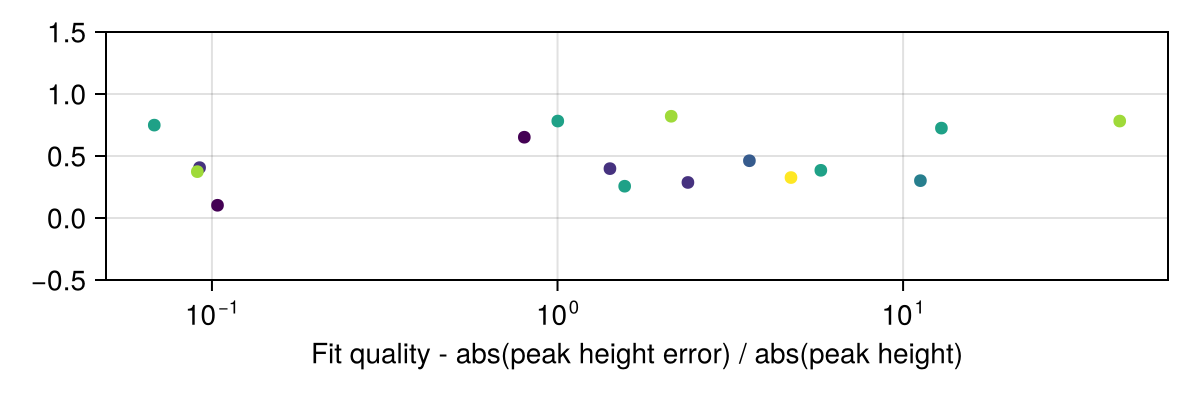

In [418]:
fap = scatter(df.fit_quality ./ abs.(df.mmrls), rand(nrow(df));
    figure=(; size=(600, 200)),
    axis=(;
        xscale=log10,
        xlabel="Fit quality - abs(peak height error) / abs(peak height)"
    ),
    # color=df.mmrls,
    color=df.num_surv,
)
ylims!(fap.axis, -0.5, 1.5)
fap

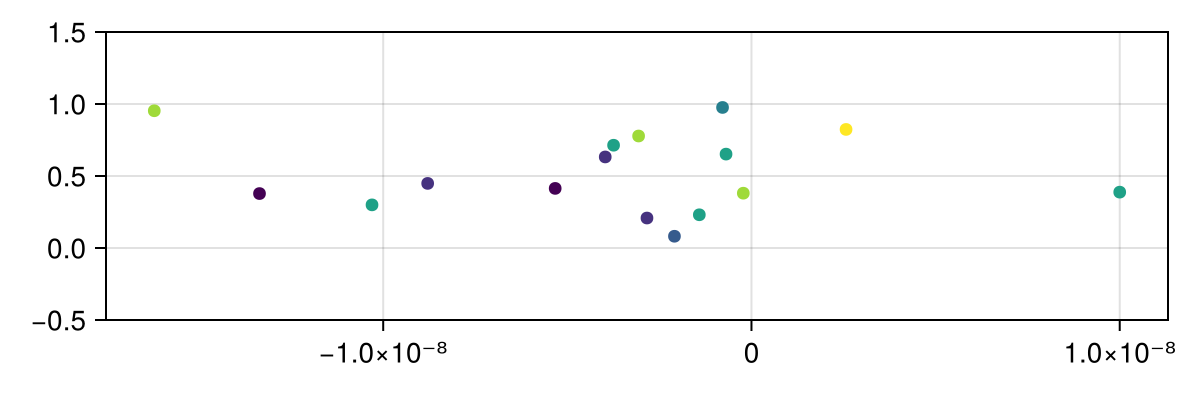

In [454]:
fap = scatter(clamp.(df.mmrls, -Inf, 1e-8), rand(nrow(df));
    figure=(; size=(600, 200)),
    axis=(;
        # xscale=log10,
        # xscale=Makie.Symlog10(1e-6)
        # xlabel="Fit quality - abs(peak height error) / abs(peak height)"
    ),
    # color=df.mmrls,
    color=df.num_surv,
)
ylims!(fap.axis, -0.5, 1.5)
fap

## Scatter plot

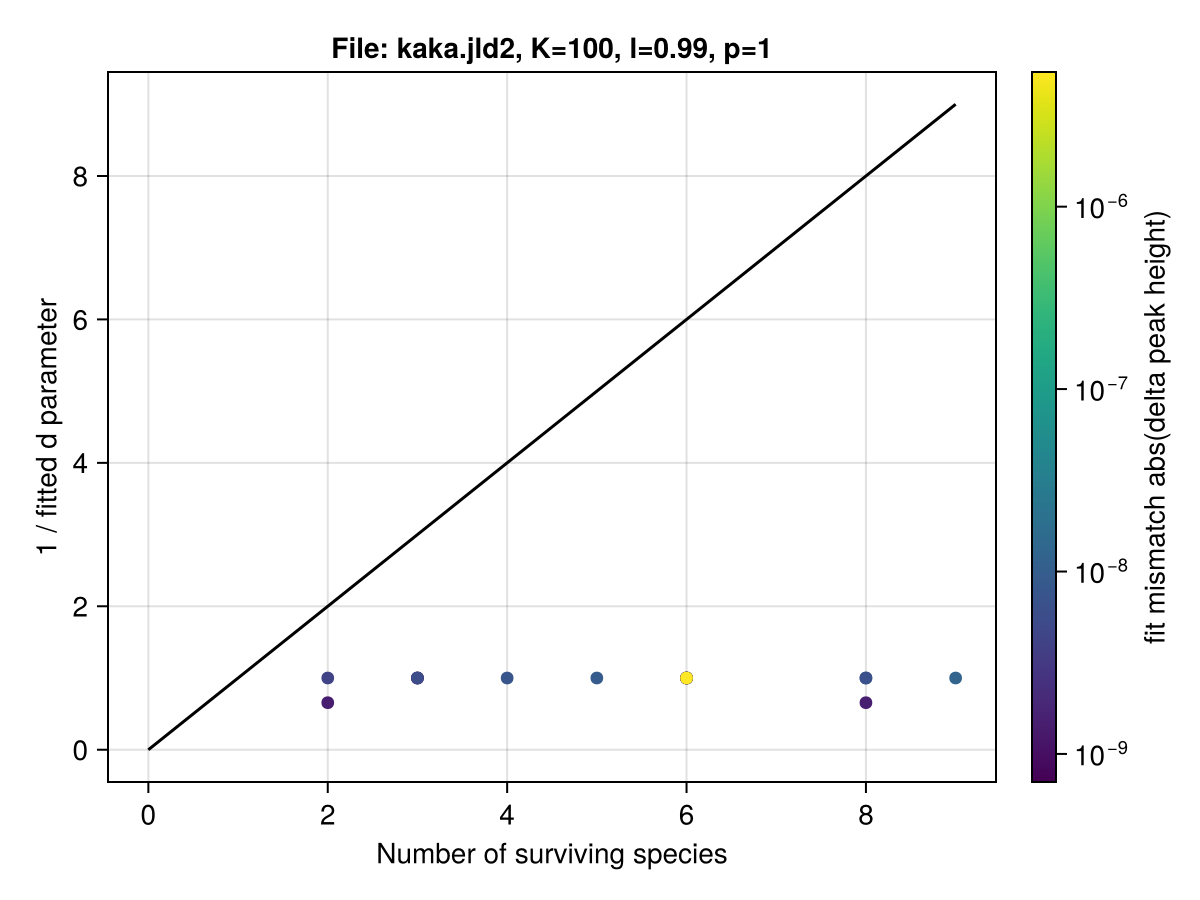

In [417]:
fap = scatter(df.num_surv, 1 ./ df.fit_ds;
    # color=clamp.(df.mmrls, minimum(filter(isposdef, df.mmrls)), Inf),
    # color=clamp.(df.tot_biom, 1e-1, Inf),
    # color=clamp.(xx, 1e-5, Inf),
    # color=xx,
    color=clamp.(df.fit_quality, 0., maximum(filter(<(1e-2), df.fit_quality))),
    # color=df.fit_func,
    colorscale=log10,
)
Colorbar(fap.figure[1,2], fap.plot;
    # label="max(real(lambdas)) - peak height"
    label="fit mismatch abs(delta peak height)"
)

fap.axis.title = (@sprintf "File: %s, K=%.5g, l=%.5g, p=%.5g" basename(f.path) fmd.K fmd.l fmd.p)
fap.axis.xlabel = "Number of surviving species"
fap.axis.ylabel = "1 / fitted d parameter"

mm = maximum(df.num_surv)
lines!(fap.axis, [0., mm], [0., mm]; color=:black)

# Makie.save("./num_surv_vs_invd_base.pdf", fap)
fap

## Looking at disprels

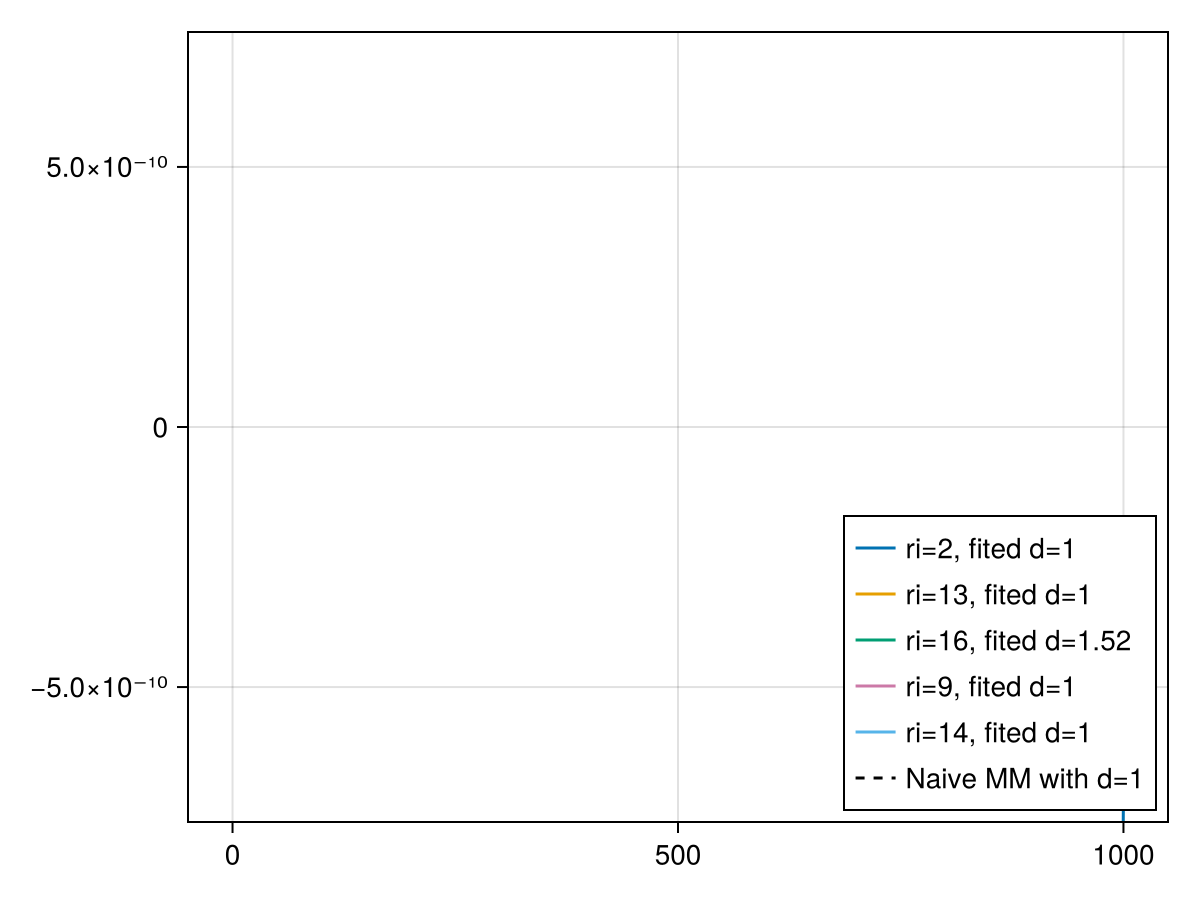

In [416]:
faa = plot_fitted_disprels(df, ks, 5)
naive_mm_mrls = get_naive_mm_mrls(ks, fmd.K, fmd.l, fmd.p; DN=fmd.DN)
lines!(faa.axis, ks, naive_mm_mrls;
    linestyle=:dash,
    color=:black,
    label="Naive MM with d=1"
)
axislegend(faa.axis; position=:rb)
# Makie.save("./fitted_disprel1.pdf", fig)
faa.figure

## Rest

In [261]:
r = df[13,:];

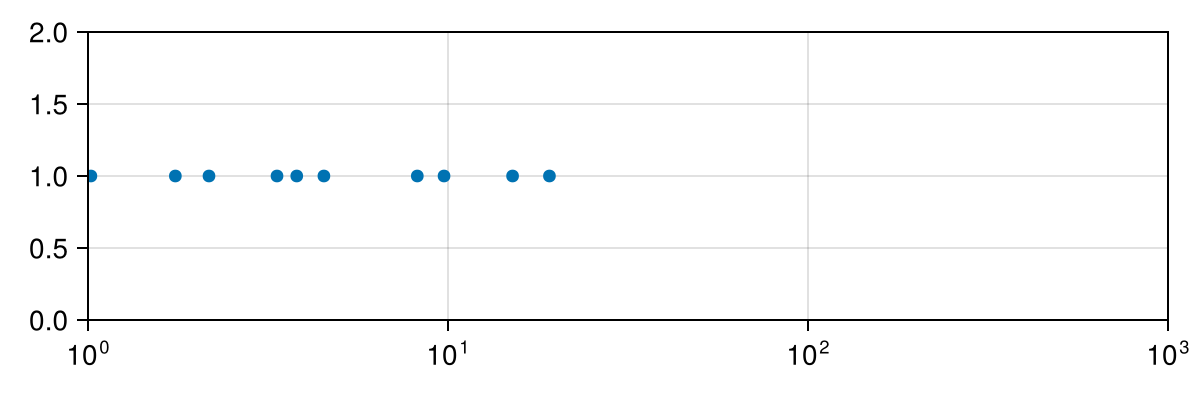

In [263]:
fap = scatter(r.final_states[1:fmd.N], fill(1, fmd.N);
    figure=(; size=(600, 200)),
    axis=(;
        xscale=log10,
        # xlabel="Fit quality - abs(peak height error) / abs(peak height)"
    ),
    # color=df.mmrls,
    # color=df.num_surv,
)
# ylims!(fap.axis, -0.5, 1.5)
fap

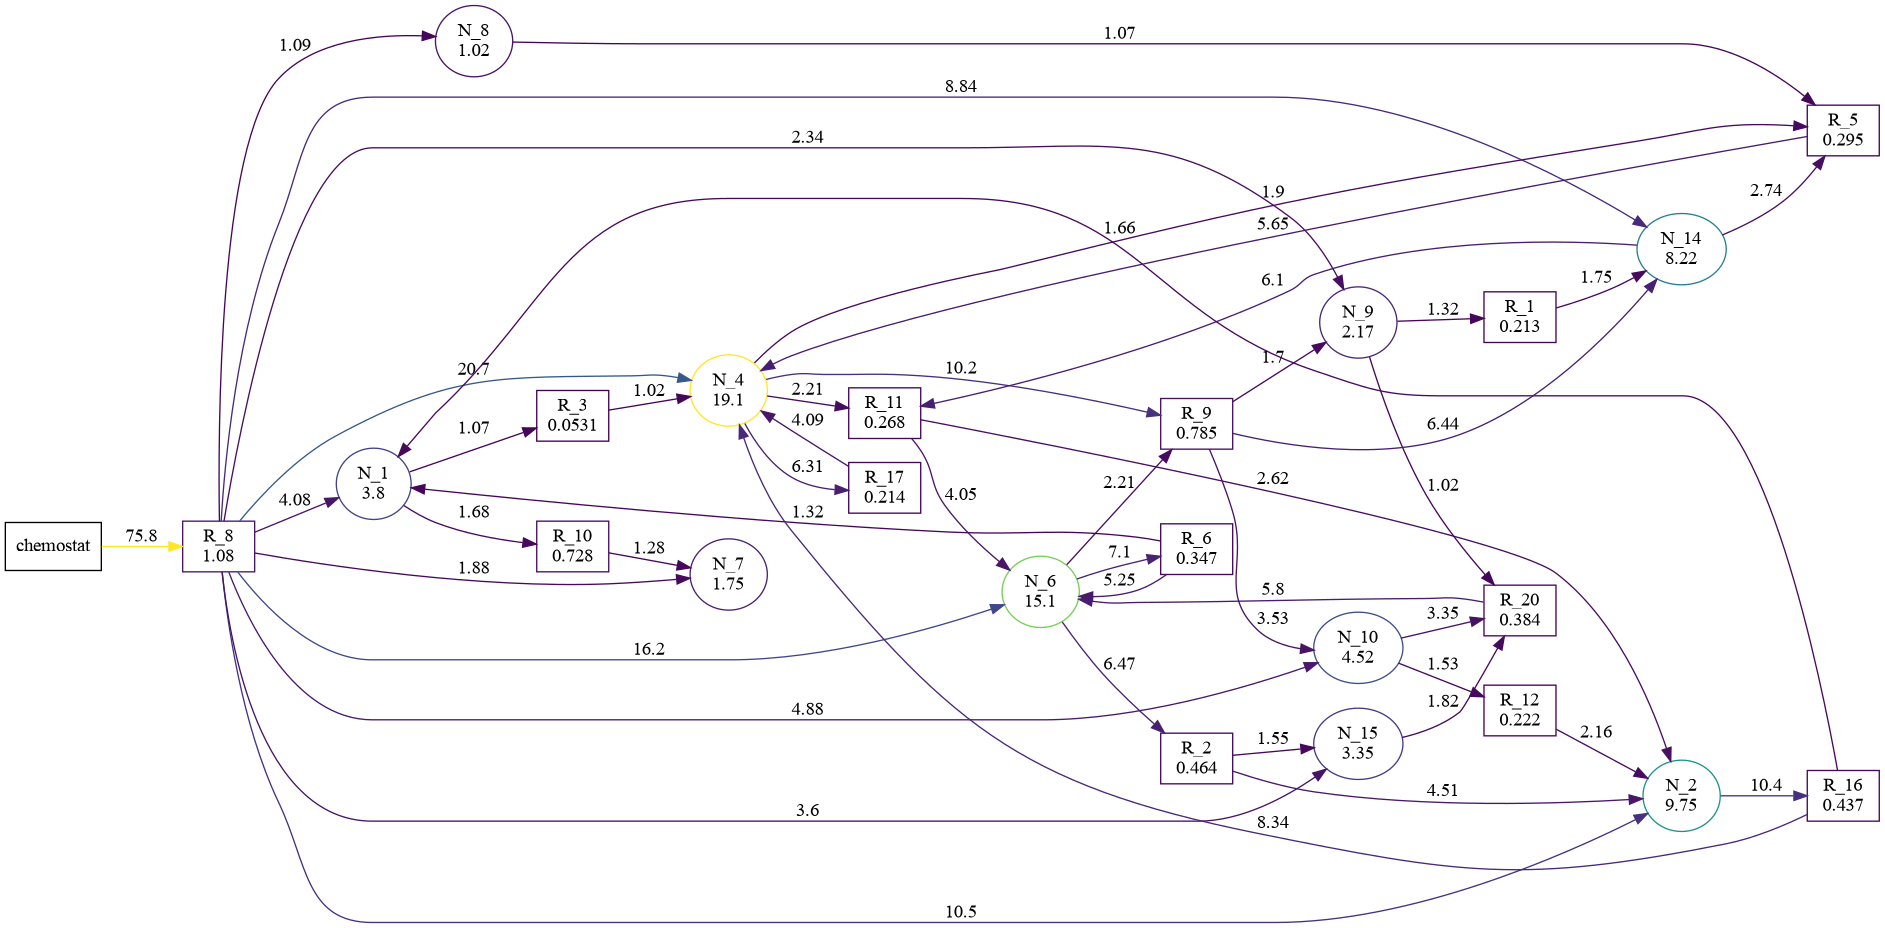

In [257]:
diagram_sfss_v3(r.params, r.final_states;
    strain_threshold=1.,
    edge_threshold=1.,
)

In [275]:
r.fit_ds

0.03576231002807634

r.fit_ds = 0.03576231002807634
r.maxresids = 4.050093593832571e-13


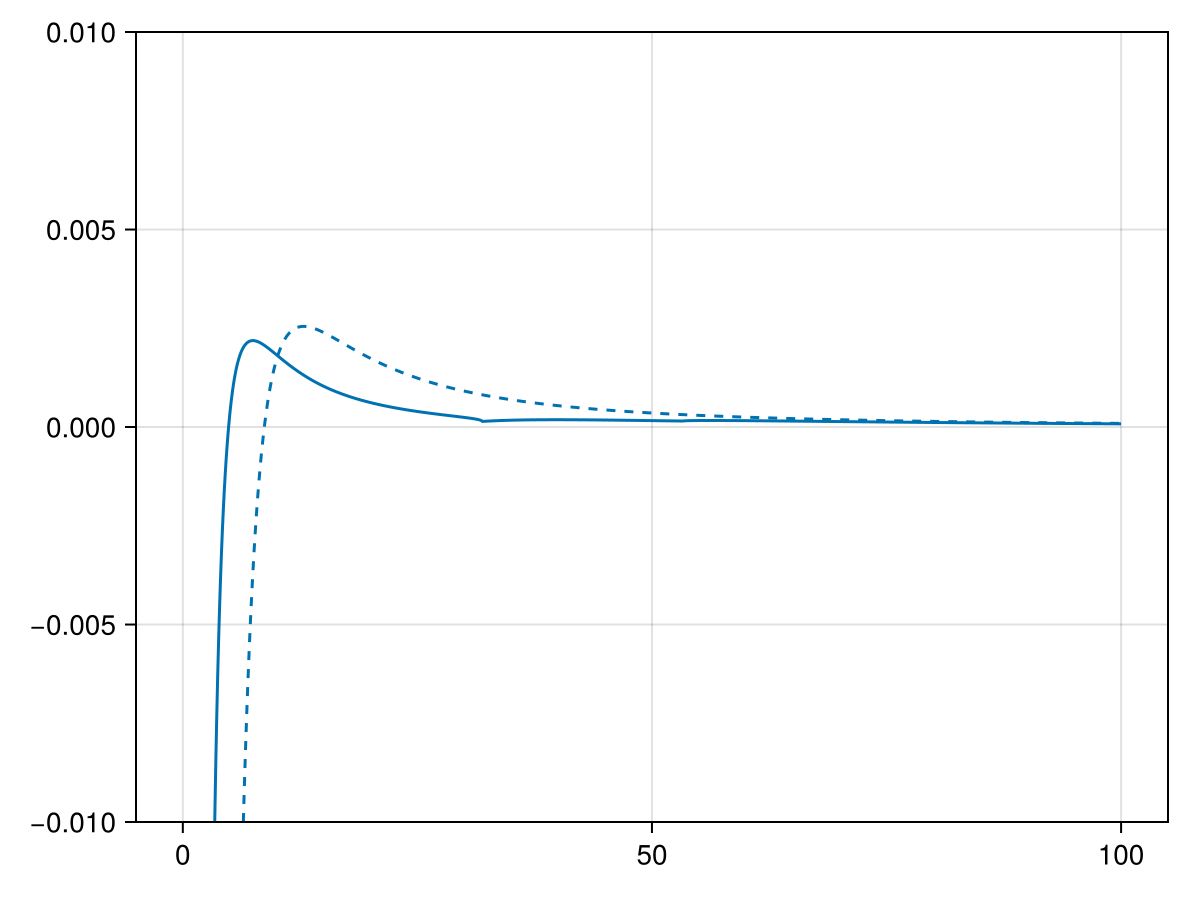

In [294]:
fig = Figure()
ax = Axis(fig[1,1])

@show r.fit_ds r.maxresids

mmp = MMParams(;
    K=fmd.K, l=fmd.l,
    m=1., c=1.,
    d=0.10,
    k=0.5,
)
mm_Ds = [fmd.DN, 1., fmd.p]
mm_ps = mmp_to_mmicrm(mmp; static=false)
mm_fs = get_mm_the_nonext_sol(mmp)
mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

lines!(ks, r.mrls)
lines!(ks, mm_mrls;
    color=Cycled(1),
    linestyle=:dash,
)

ylims!(ax, -0.01, 0.01)

fig

## Optimizing k and D[1,2,1] too

In [380]:
opt_factor = 1e-5
test_threshold = 1e-9

opt_r = optimize([1., 0., 0.9], NelderMead()) do u
    mmp = MMParams(;
        K=fmd.K, l=fmd.l,
        m=1., c=1.,
        d=u[1],
        k=u[2],
    )
    mm_Ds = [fmd.DN, 1., fmd.p]
    mm_ps = mmp_to_mmicrm(mmp; static=false)
    mm_ps.D[1,2,1] = u[3]

    mm_p = make_mmicrm_problem(mm_ps, [10000., 0., 0.], 1e8)
    tol = 1e-9
    mm_s = solve(mm_p, QNDF();
        callback=CallbackSet(make_timer_callback(10.), PositiveDomain([1., 0., 0.])),
        abstol=tol,
        reltol=tol,
    )
    mm_fs = mm_s.u[end]

    mresid = mmicrmmaxresid(mm_fs, mm_ps)
    if (mresid > test_threshold) || (mm_fs[1] < test_threshold)
        return Inf
    end

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)
    (mm_mmrl, mm_ii) = findmax(mm_mrls)
    (r_mmrl, r_ii) = findmax(r.mrls)
    (mm_mmrl - r_mmrl)^2 + opt_factor * (ks[mm_ii] - ks[r_ii])^2
end;
@show opt_r.minimum opt_r.minimizer;

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consid

opt_r.minimum = 2.0361758170563895e-5
opt_r.minimizer = [0.4166695101824518, 0.04411474815798375, 0.164116958128501]


r.fit_ds = 0.03576231002807634
r.maxresids = 4.050093593832571e-13


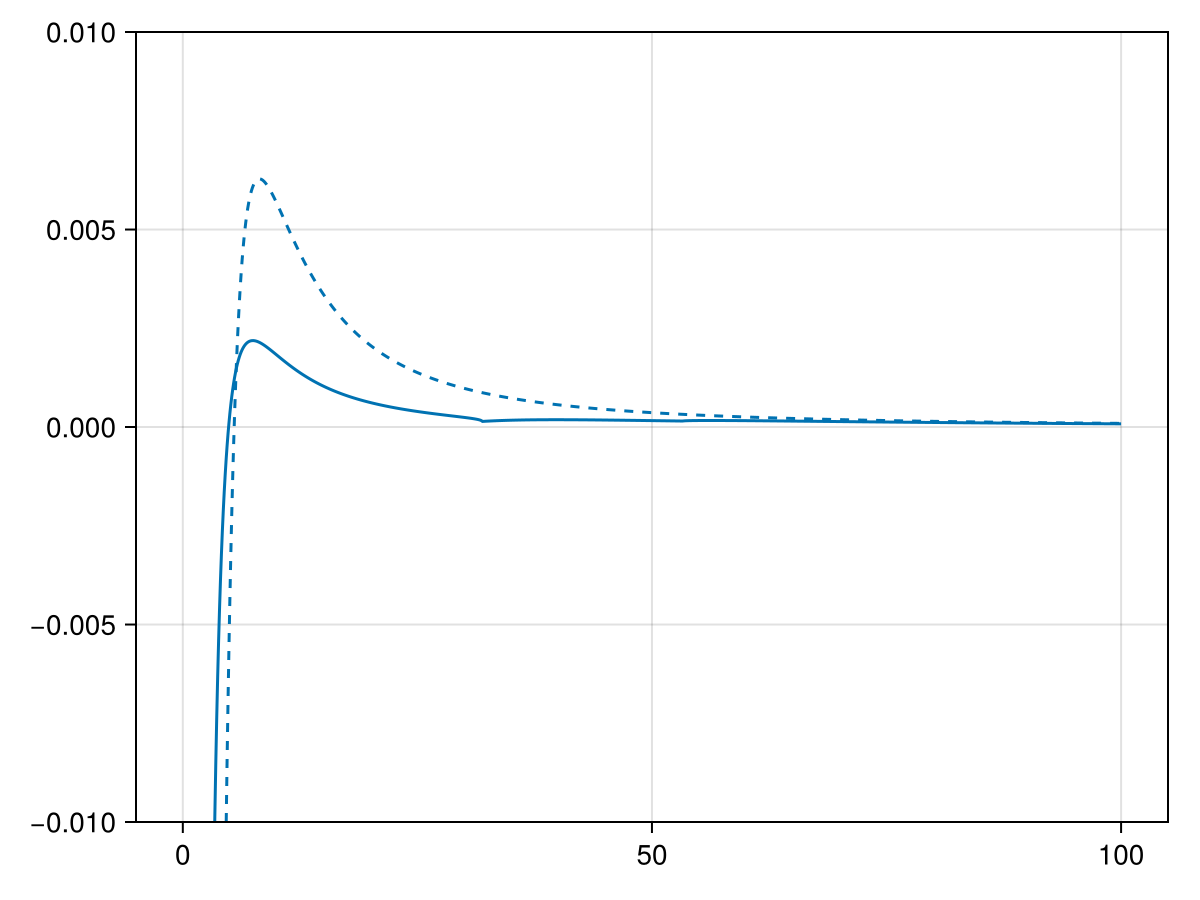

In [381]:
fig = Figure()
ax = Axis(fig[1,1])

@show r.fit_ds r.maxresids

mmp = MMParams(;
    K=fmd.K, l=fmd.l,
    m=1., c=1.,
    d=opt_r.minimizer[1],
    k=opt_r.minimizer[2],
)
mm_Ds = [fmd.DN, 1., fmd.p]
mm_ps = mmp_to_mmicrm(mmp; static=false)
mm_ps.D[1,2,1] = opt_r.minimizer[3]

mm_p = make_mmicrm_problem(mm_ps, [10000., 0., 0.], 1e8)
tol = 1e-9
mm_s = solve(mm_p, QNDF();
    callback=CallbackSet(make_timer_callback(10.), PositiveDomain([1., 0., 0.])),
    abstol=tol,
    reltol=tol,
)
mm_fs = mm_s.u[end]

# mm_fs = get_mm_the_nonext_sol(mmp)

mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

lines!(ks, r.mrls)
lines!(ks, mm_mrls;
    color=Cycled(1),
    linestyle=:dash,
)

ylims!(ax, -0.01, 0.01)

fig